# [title] One-state Model: the Prior and the Schedule Design

**Question.** Do the Prior Sampler and the Schedule Generator produce what
[decision 0005](../../docs/decisions/0005-one-state-model-published-form.md) says, and do
the Sittings they lead to look like those of real experiments? Terms:
[glossary](../../docs/glossary.md).

**Scope.** Step C2 of [#12](https://github.com/opherdonchin/MotorAdpatationSBI/issues/12).
The Prior Sampler is `sample_prior`, in
[`src/models/one_state.py`](../../src/models/one_state.py); the Schedule Generator is
`sample_schedule`, in
[`src/designs/visuomotor_adaptation_experiment.py`](../../src/designs/visuomotor_adaptation_experiment.py).
The Simulator itself was checked in [one_state_simulator.ipynb](one_state_simulator.ipynb).

**Checks:**

1. *Prior ranges:* each quantity's central 95% interval and median, over many draws,
   are the ones in the decision's table.
2. *Schedules:* Sitting lengths cover about 200 to 1,500 Trials (central 95%), as the
   decision states, and the mix of Trial Types varies between Sittings as intended.
3. *Simulated Sittings,* for Opher to judge by eye.

In [1]:
# [imports]
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import expit, logit
from scipy.stats import norm

from designs.visuomotor_adaptation_experiment import TRIAL_TYPES, sample_schedule
from models.one_state import sample_prior, simulate_sitting

In [2]:
# [config] Root seed, Prior and Schedule Design constants, and the size of each check
root_seed = 222072369819731305528817987619269270974  # secrets.randbits(128)

# Decision 0005: each part of the Prior is normal on an unbounded scale, and the stated range is
# its central 95% interval. Units: the perturbation size.
range_a = (0.75, 0.999)
range_b = (0.01, 0.5)
range_sigma_epsilon = (1 / 15, 1 / 3)
range_ratio = (1 / 15, 1 / 5)  # sigma_eta / sigma_epsilon
range_block_len = (10, 250)  # trials

z95 = norm.ppf(0.975)
prior = {
    "mu_logit_A": logit(range_a).mean(), "sigma_logit_A": np.ptp(logit(range_a)) / (2 * z95),
    "mu_logit_B": logit(range_b).mean(), "sigma_logit_B": np.ptp(logit(range_b)) / (2 * z95),
    "mu_log_sigma_epsilon": np.log(range_sigma_epsilon).mean(),
    "sigma_log_sigma_epsilon": np.ptp(np.log(range_sigma_epsilon)) / (2 * z95),
    "mu_log_ratio": np.log(range_ratio).mean(), "sigma_log_ratio": np.ptp(np.log(range_ratio)) / (2 * z95),
}
schedule_design = {
    "n_blocks_min": 5, "n_blocks_max": 16,
    "mu_log_block_len": np.log(range_block_len).mean(),
    "sigma_log_block_len": np.ptp(np.log(range_block_len)) / (2 * z95),
    "trial_type_concentration": 3.0,
}

n_prior_draws = 200_000  # enough that sample quantiles are within about 0.3% of the true ones
n_schedules = 5_000  # Schedules drawn to describe lengths and mixes
n_examples = 9  # simulated Sittings shown

pd.Series({**prior, **schedule_design}).round(3)

mu_logit_A                   4.003
sigma_logit_A                1.482
mu_logit_B                  -2.298
sigma_logit_B                1.172
mu_log_sigma_epsilon        -1.903
sigma_log_sigma_epsilon      0.411
mu_log_ratio                -2.159
sigma_log_ratio              0.280
n_blocks_min                 5.000
n_blocks_max                16.000
mu_log_block_len             3.912
sigma_log_block_len          0.821
trial_type_concentration     3.000
dtype: float64

In [3]:
# [rng] One root generator, one stream per purpose
rng = np.random.default_rng(root_seed)
rng_prior, rng_schedule, rng_example = rng.spawn(3)

In [4]:
# [plot-style] Colours and axes shared by the figures
blue, muted, grid, shade = "#2a78d6", "#898781", "#e1e0d9", "#f0efec"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": muted, "axes.labelcolor": "#52514e",
    "xtick.color": muted, "ytick.color": muted,
    "axes.titlesize": 9, "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "figure.constrained_layout.use": True,
})

## [check-1] Check 1: the Prior

`sample_prior` draws $\mathrm{logit}(A)$, $\mathrm{logit}(B)$, $\log\sigma_\varepsilon$
and $\log(\sigma_\eta/\sigma_\varepsilon)$ from independent normals and transforms them.
The transforms are monotone, so the 2.5% and 97.5% quantiles of each drawn quantity must
be the ends of its stated range, and its median must be the transformed mean of the
normal. $\sigma_\eta$ has no range of its own; its interval is reported for information.

In [5]:
# [check-prior-ranges] Quantiles of the drawn parameters against the stated ranges
theta = sample_prior(rng_prior, n_prior_draws, prior)
A, B, sigma_eta, sigma_epsilon = theta.T
drawn = {"A": A, "B": B, "sigma_epsilon": sigma_epsilon, "ratio": sigma_eta / sigma_epsilon, "sigma_eta": sigma_eta}
stated = {"A": range_a, "B": range_b, "sigma_epsilon": range_sigma_epsilon, "ratio": range_ratio}
median_expected = {
    "A": expit(prior["mu_logit_A"]), "B": expit(prior["mu_logit_B"]),
    "sigma_epsilon": np.exp(prior["mu_log_sigma_epsilon"]), "ratio": np.exp(prior["mu_log_ratio"]),
}
pd.DataFrame({
    name: {
        "stated 2.5%": stated.get(name, (np.nan, np.nan))[0],
        "drawn 2.5%": np.quantile(x, 0.025),
        "expected median": median_expected.get(name, np.nan),
        "drawn median": np.median(x),
        "stated 97.5%": stated.get(name, (np.nan, np.nan))[1],
        "drawn 97.5%": np.quantile(x, 0.975),
    }
    for name, x in drawn.items()
}).T.round(4)

,stated 2.5%,drawn 2.5%,expected median,drawn median,stated 97.5%,drawn 97.5%
A,0.7500,0.7487,0.9821,0.9820,0.9990,0.9990
B,0.0100,0.0100,0.0913,0.0917,0.5000,0.5038
sigma_epsilon,0.0667,0.0666,0.1491,0.1493,0.3333,0.3330
ratio,0.0667,0.0668,0.1155,0.1154,0.2000,0.1997
sigma_eta,NaN,0.0065,NaN,0.0172,NaN,0.0454


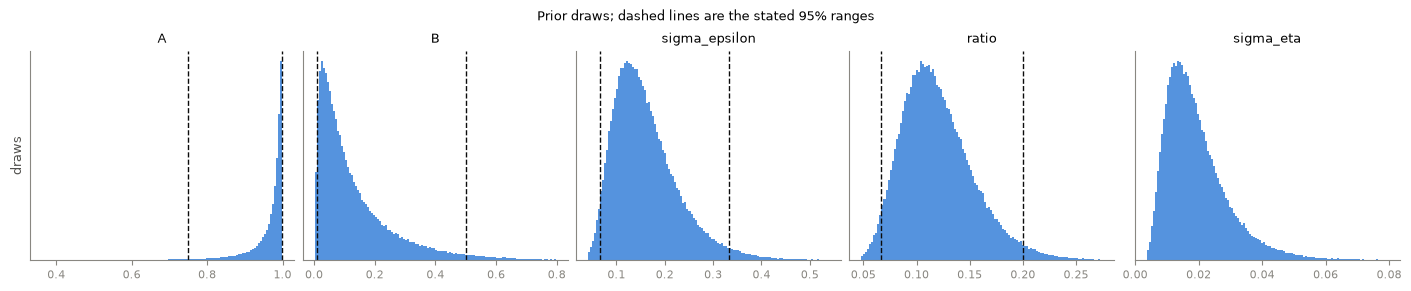

In [6]:
# [prior-histograms] What the Prior looks like on the natural scale
fig, axes = plt.subplots(1, 5, figsize=(14, 2.8))
for ax, (name, x) in zip(axes, drawn.items()):
    ax.hist(x, bins=120, range=tuple(np.quantile(x, [0.001, 0.999])), color=blue, alpha=0.8)
    for edge in stated.get(name, ()):
        ax.axvline(edge, color="#0b0b0b", lw=1, ls="--")
    ax.set_title(name)
    ax.set_yticks([])
axes[0].set_ylabel("draws")
fig.suptitle("Prior draws; dashed lines are the stated 95% ranges", fontsize=9)
plt.show()

## [check-2] Check 2: the Schedules

Each Schedule has 5 to 16 Blocks of log-normal length, so a Sitting's length is a sum of
random Block lengths. Each Sitting also draws its own mix of the four Trial Types
(baseline, +1, -1, no vision) from a symmetric Dirichlet with concentration 3: a single
Trial Type's share of the Blocks then has a Beta(3, 9) distribution, with median 0.24 and
central 95% interval 0.06 to 0.52. The share of *Trials* of each Trial Type, shown below,
varies a little more, because Blocks differ in length and the first Block is always a
baseline.

In [7]:
# [check-schedules] Sitting lengths and the mix of Trial Types
schedules = [sample_schedule(rng_schedule, schedule_design) for _ in range(n_schedules)]
T = np.array([len(schedule["p"]) for schedule in schedules])
trial_share = np.array([
    [np.mean((schedule["p"] == c["p"]) & (schedule["v"] == c["v"])) for c in TRIAL_TYPES.values()]
    for schedule in schedules
])
no_vision_trials = np.array([np.sum(schedule["v"] == 0) for schedule in schedules])

summary = pd.DataFrame({
    "trials per sitting": np.quantile(T, [0.025, 0.5, 0.975]),
    "no-vision trials per sitting": np.quantile(no_vision_trials, [0.025, 0.5, 0.975]),
    **{f"share of trials: {kind}": np.quantile(trial_share[:, k], [0.025, 0.5, 0.975]) for k, kind in enumerate(TRIAL_TYPES)},
}, index=["2.5%", "median", "97.5%"]).T
summary.round(3)

,2.5%,median,97.5%
trials per sitting,233.000,696.000,1442.050
no-vision trials per sitting,0.000,115.000,633.000
share of trials: baseline,0.036,0.298,0.805
share of trials: +1,0.000,0.180,0.679
share of trials: -1,0.000,0.180,0.691
share of trials: no vision,0.000,0.182,0.692


In [8]:
# [missing-kinds] How often a Sitting has no Block of a Trial Type at all
pd.Series({
    **{f"no {kind} block": np.mean(trial_share[:, k] == 0) for k, kind in enumerate(TRIAL_TYPES) if kind != "baseline"},
    "no perturbation block at all": np.mean((trial_share[:, 1] == 0) & (trial_share[:, 2] == 0)),
}, name="fraction of sittings").round(3)

no +1 block                     0.164
no -1 block                     0.171
no no vision block              0.165
no perturbation block at all    0.024
Name: fraction of sittings, dtype: float64

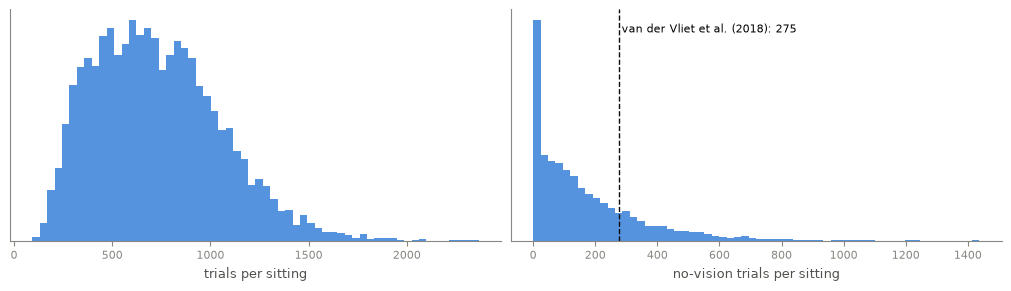

In [9]:
# [schedule-figures] Distribution of Sitting length and of no-vision Trials
fig, axes = plt.subplots(1, 2, figsize=(10, 2.8))
axes[0].hist(T, bins=60, color=blue, alpha=0.8)
axes[0].set_xlabel("trials per sitting")
axes[1].hist(no_vision_trials, bins=60, color=blue, alpha=0.8)
axes[1].axvline(275, color="#0b0b0b", lw=1, ls="--")
axes[1].text(285, axes[1].get_ylim()[1] * 0.9, "van der Vliet et al. (2018): 275", fontsize=8)
axes[1].set_xlabel("no-vision trials per sitting")
for ax in axes:
    ax.set_yticks([])
plt.show()

## [check-3] Check 3: simulated Sittings

Each panel is one Sitting: its own Schedule, its own parameter values drawn from the
Prior, and the movements the Simulator produces. Grey bands are no-vision Blocks; the grey line
is the perturbation; dots are movements. A learner compensates by moving to $-p$.

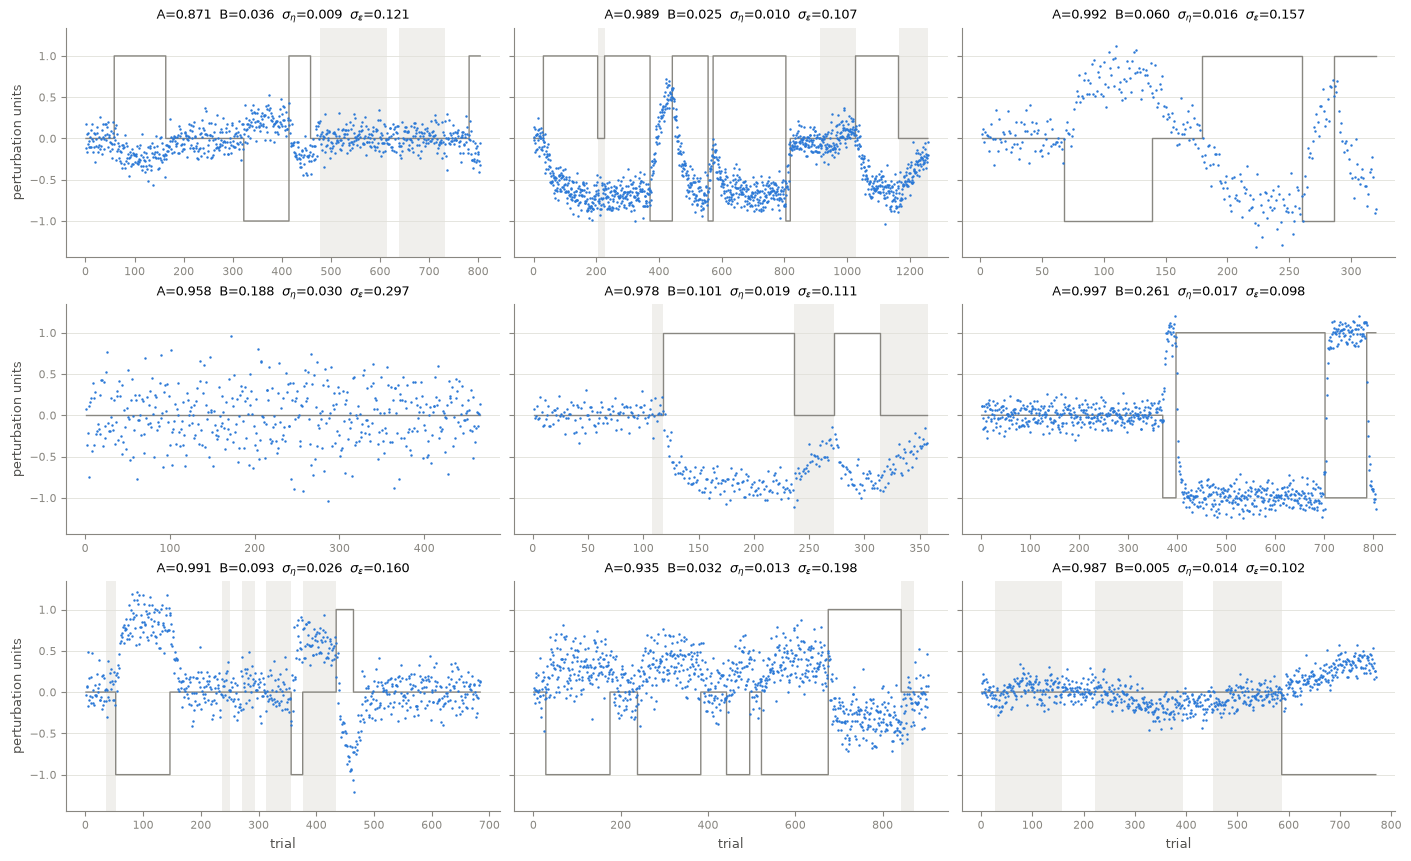

In [10]:
# [generated-sittings] Sittings from the Prior Sampler, the Schedule Generator and the Simulator
thetas = sample_prior(rng_example, n_examples, prior)
fig, axes = plt.subplots(3, 3, figsize=(14, 8.5), sharey=True)
for ax, th in zip(axes.flat, thetas):
    schedule = sample_schedule(rng_example, schedule_design)
    p, v = schedule["p"], schedule["v"]
    y = simulate_sitting(rng_example, th, schedule)[0]["y"]
    trial = np.arange(1, len(p) + 1)
    edges = np.nonzero(np.diff(np.r_[1, v, 1]) != 0)[0].reshape(-1, 2)
    for start, stop in edges:
        ax.axvspan(start + 0.5, stop + 0.5, color=shade, lw=0)
    ax.step(trial, p, where="mid", color=muted, lw=1)
    ax.plot(trial, y, ".", color=blue, ms=1.5)
    ax.set_title("A={:.3f}  B={:.3f}  $\\sigma_\\eta$={:.3f}  $\\sigma_\\varepsilon$={:.3f}".format(*th))
    ax.grid(axis="y", color=grid, lw=0.6)
for ax in axes[-1]:
    ax.set_xlabel("trial")
for ax in axes[:, 0]:
    ax.set_ylabel("perturbation units")
plt.show()

## [results] What this shows

1. **Prior Sampler: pass.** Over 200,000 draws, the 2.5% and 97.5% quantiles and the median of
   $A$, $B$, $\sigma_\varepsilon$ and $\sigma_\eta/\sigma_\varepsilon$ match the
   decision's table within sampling error (`[check-prior-ranges]`). The implied
   $\sigma_\eta$ has median 0.017 and central 95% interval 0.0065 to 0.045.
2. **Schedule Generator: as intended.** Sittings have about 230 to 1,440 Trials (central
   95%), median about 700 (`[check-schedules]`). Blocks have a median of 50 Trials and
   can last up to about 250.
3. **Simulated Sittings:** for Opher to judge (`[generated-sittings]`).

**Worth deciding on.** With 5 to 16 Blocks and each Block's Trial Type drawn independently,
many Sittings lack a Trial Type altogether (`[missing-kinds]`): about 16% have no no-vision
Block, about 17% no +1 Block, about 17% no -1 Block, and 2.4% no perturbation at all.
Those Sittings say little about the noise ratio or, in the last case, the adaptation rate.
That is realistic variety, and the Inference Engine has to learn to report the
resulting uncertainty, but if it makes training inefficient the Schedule Design could
require each Trial Type at least once.